# Exploratory Data Analysis

In [12]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/faang_stock_prices.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort chronologically
df = df.sort_values("Date")

# Preview dataset
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


In [13]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (14964, 19)

Missing Values:
Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_7              0
SMA_21             0
EMA_12             0
EMA_26             0
RSI_14             0
MACD               0
MACD_Signal        0
Bollinger_Upper    0
Bollinger_Lower    0
Daily_Return       0
Volatility_7d      0
Next_Day_Close     0
dtype: int64

Duplicate Rows: 0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             14964 non-null  datetime64[ns]
 1   Ticker           14964 non-null  object        
 2   Open             14964 non-null  float64       
 3   High             14964 non-null  float64       
 4   Low              14964 non-null  float64       
 5   Close            14964 non-null  float64       
 6   Volume           14964 non-null  int64         
 7   SMA_7            14964 non-null  float64       
 8   SMA_21           14964 non-null  float64       
 9   EMA_12           14964 non-null  float64       
 10  EMA_26           14964 non-null  float64       
 11  RSI_14           14964 non-null  float64       
 12  MACD             14964 non-null  float64       
 13  MACD_Signal      14964 non-null  float64       
 14  Bollinger_Upper  14964 non-null  float64   

In [15]:
df.describe()

,Date,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
count,14964,14964.000000,14964.000000,14964.000000,14964.000000,1.496400e+04,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000
mean,2021-02-03 05:47:00.529270528,147.969959,149.643762,146.256716,147.999839,1.186247e+08,147.631588,146.746646,147.314335,146.428158,55.686976,0.886176,0.888239,156.048174,137.572513,0.001335,0.018537,148.126287
min,2016-02-23 00:00:00,0.762756,0.777392,0.746413,0.767738,4.726100e+06,0.710800,0.683503,0.704268,0.691066,3.180003,-33.155902,-30.727270,0.780719,0.569458,-0.263901,0.001171,0.767738
25%,2018-08-13 00:00:00,50.094322,50.468777,49.669161,50.083026,2.428050e+07,49.906533,49.334041,49.600781,49.146090,43.754097,-0.331123,-0.283075,51.982837,47.077112,-0.008375,0.010449,50.149251
50%,2021-02-03 12:00:00,123.841343,125.102966,122.262753,123.922924,4.432600e+07,123.301276,122.667958,123.067546,122.222704,56.381405,0.507975,0.491224,131.496224,114.337861,0.001286,0.015466,124.013718
75%,2023-07-28 00:00:00,189.299623,191.429458,186.986899,189.079613,1.057329e+08,188.811102,187.325549,187.740894,186.739774,67.819077,2.160937,2.068120,199.721259,176.264492,0.011626,0.022748,189.254452
max,2026-01-22 00:00:00,789.972167,795.064526,779.657506,788.823792,3.692928e+09,775.982954,762.484980,766.193137,757.613109,100.000000,29.441884,26.790650,813.954233,734.580075,0.298067,0.120255,788.823792
std,NaN,132.599874,134.001750,131.065146,132.547711,1.889461e+08,132.261571,131.557653,131.956650,131.170115,16.597436,4.177106,3.932864,139.825874,123.751294,0.022069,0.012431,132.632577


In [16]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 2016-02-23 00:00:00
End Date: 2026-01-22 00:00:00


In [17]:
print("Unique Stocks:")
print(df["Ticker"].unique())

Unique Stocks:
['AAPL' 'AMZN' 'GOOGL' 'META' 'MSFT' 'NVDA']


# Visualizations

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

## Line Chart Comparison of FAANG Stock Closing Prices Over Time

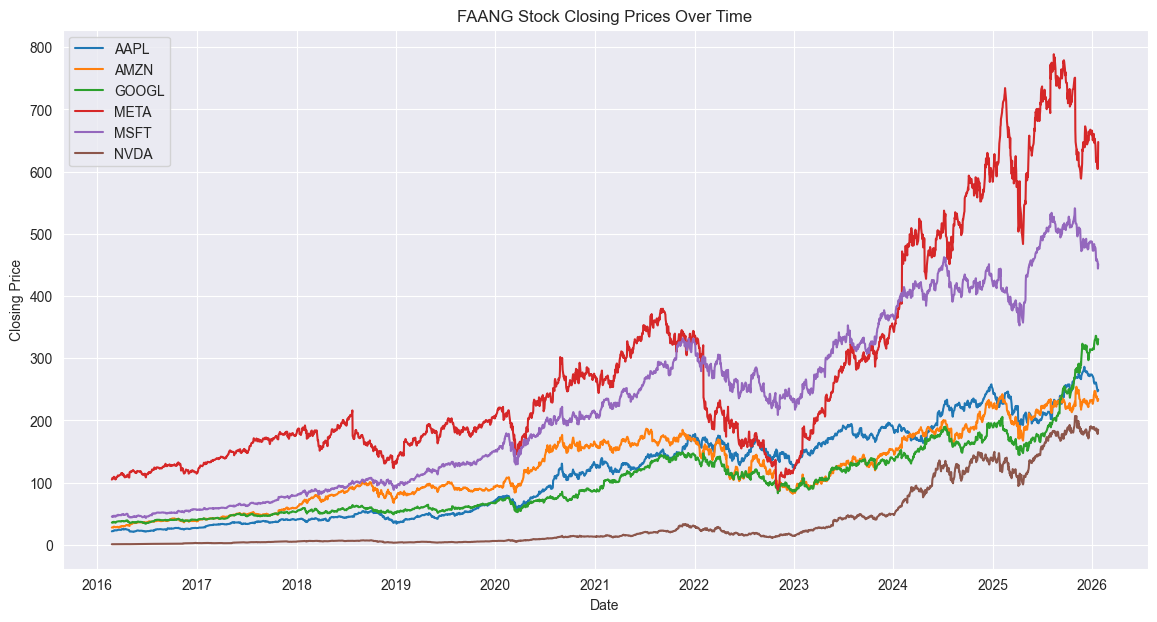

In [21]:
plt.figure(figsize=(14,7))

# Loop through each company ticker
for ticker in df["Ticker"].unique():
    
    # Filter data for current company
    company_df = df[df["Ticker"] == ticker]
    
    # Plot closing prices
    plt.plot(
        company_df["Date"],
        company_df["Close"],
        label=ticker
    )

# Chart labels
plt.title("FAANG Stock Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

# Show legend
plt.legend()

# Display chart
plt.show()

## Line Chart Comparison for Distribution of Daily Returns for FAANG Stocks

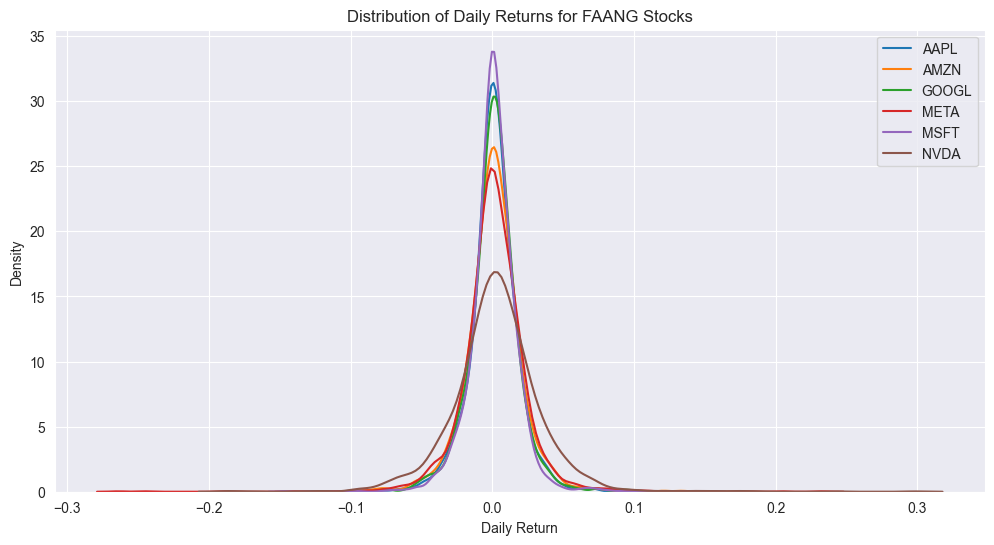

In [23]:
# Create chart size
plt.figure(figsize=(12,6))

# Loop through each unique company ticker
for ticker in df["Ticker"].unique():
    
    # Filter dataframe for ONE company
    company_df = df[df["Ticker"] == ticker].copy()
    
    # Create previous day's closing price
    company_df["Prev_Close"] = company_df["Close"].shift(1)
    
    # Calculate daily return
    company_df["Daily_Return"] = (
        (company_df["Close"] - company_df["Prev_Close"])
        / company_df["Prev_Close"]
    )
    
    # Plot smooth distribution curve
    sns.kdeplot(
        company_df["Daily_Return"].dropna(),
        label=ticker
    )

# Add chart title and labels
plt.title("Distribution of Daily Returns for FAANG Stocks")
plt.xlabel("Daily Return")
plt.ylabel("Density")

# Show company labels
plt.legend()

# Display chart
plt.show()

## Correlation Heatmap for FAANG Feature Correlation

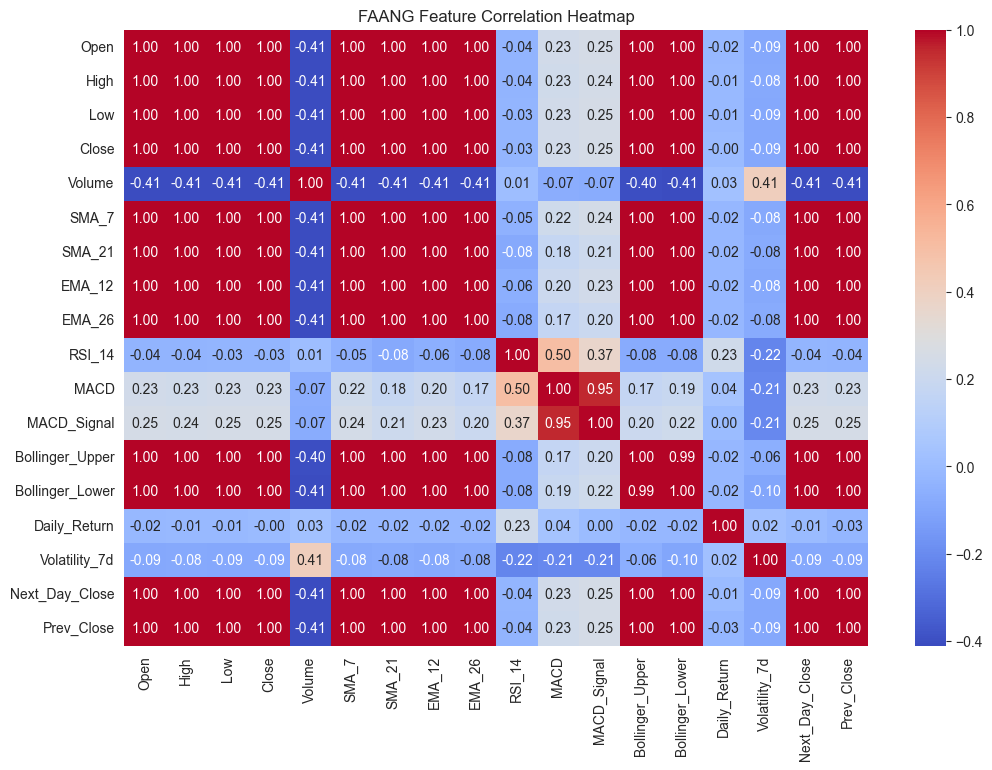

In [27]:
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,      # <-- this adds numbers
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("FAANG Feature Correlation Heatmap")
plt.show()

## Line Chart for 20-Day Rolling Volatility Across FAANG Stocks

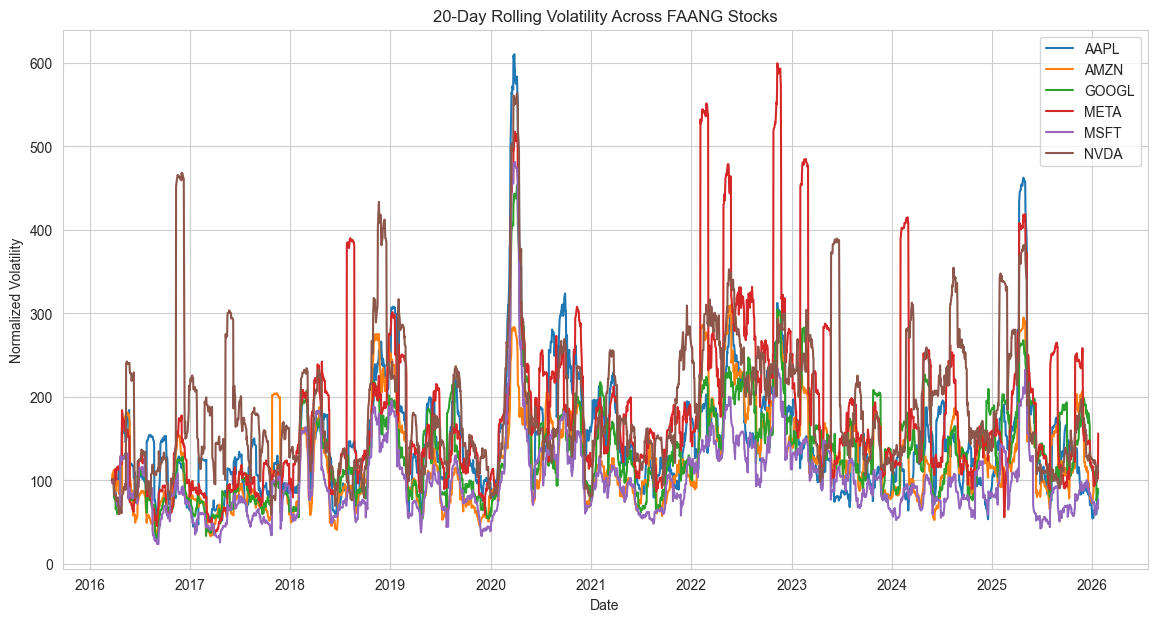

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for ticker in df["Ticker"].unique():
    
    company_df = df[df["Ticker"] == ticker].copy()
    company_df = company_df.sort_values("Date")
    
    # returns
    company_df["Prev_Close"] = company_df["Close"].shift(1)
    company_df["Daily_Return"] = (
        (company_df["Close"] - company_df["Prev_Close"])
        / company_df["Prev_Close"]
    )
    
    # volatility
    company_df["Volatility_20"] = company_df["Daily_Return"].rolling(20).std()
    
    # remove NaNs
    company_df = company_df.dropna(subset=["Volatility_20"])
    
    # normalize (ONLY AFTER it exists)
    company_df["Volatility_20_norm"] = (
        company_df["Volatility_20"] / company_df["Volatility_20"].iloc[0]
    ) * 100
    
    plt.plot(
        company_df["Date"],
        company_df["Volatility_20_norm"],
        label=ticker
    )

plt.title("20-Day Rolling Volatility Across FAANG Stocks")
plt.xlabel("Date")
plt.ylabel("Normalized Volatility")
plt.legend()
plt.show()

## Box Plot for Volatility Comparison Across FAANG Stocks

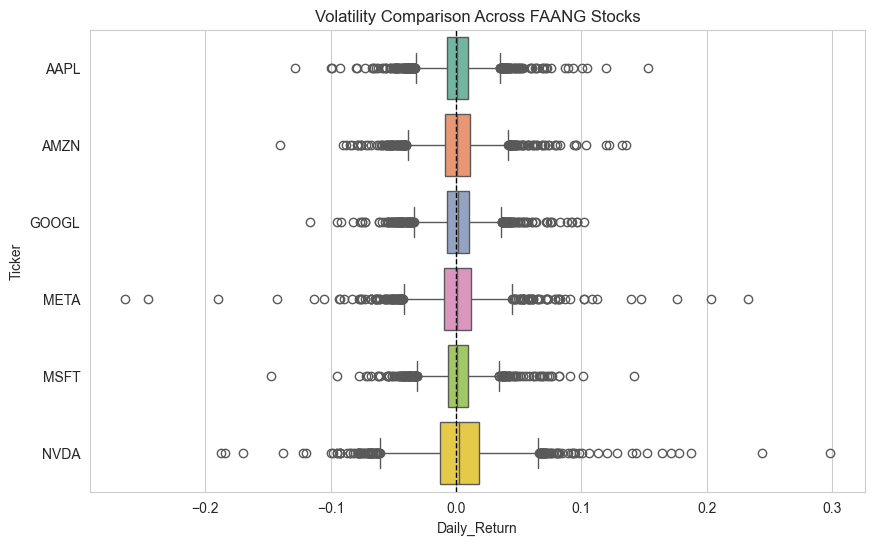

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

# compute returns
df = df.sort_values("Date")
df["Prev_Close"] = df.groupby("Ticker")["Close"].shift(1)
df["Daily_Return"] = (df["Close"] - df["Prev_Close"]) / df["Prev_Close"]

sns.boxplot(
    data=df,
    y="Ticker",
    x="Daily_Return",
    hue="Ticker",
    palette="Set2"
)

plt.title("Volatility Comparison Across FAANG Stocks")
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.legend([], [], frameon=False)  # hides duplicate legend

plt.show()